## Import Libraries

In [96]:
# import libraries
import pandas as pd
import numpy as np
from pathlib import Path
from inflation_forecast.pre_process import stationary_transform, report_missings, sample_split, remove_missing_col
from inflation_forecast.visualization import visualize_series, visualize_loss, visualize_predict
from inflation_forecast.feature_engineering import x_fe_pipeline, y_fe_pipeline, create_ahead_lag
from inflation_forecast.model import create_data_loaders, create_MLP, MLP_training, make_predict

## Data Pre-Process

In [97]:
# read the FRED_MD csv file, convert to pandas dataframe
root_dir = Path.cwd().parent
FRED_MD = pd.read_csv(str(root_dir) + "/data/FRED_MD/2026-02-MD.csv")
transforms = pd.read_csv(str(root_dir) + "/data/FRED_MD/transform.csv")

In [98]:
# conduct stationarity transformations
FRED_transformed = stationary_transform(FRED_MD, transforms)
# drop first two rows as they have abundant nan due to double difference
FRED_transformed = FRED_transformed.iloc[2:]
# drop last row as many variables of it has not updated
FRED_transformed = FRED_transformed.iloc[:-1]
# transform sasdate to pd.date format
FRED_transformed["sasdate"] = pd.to_datetime(FRED_transformed["sasdate"])
FRED_MD["sasdate"] = pd.to_datetime(FRED_MD["sasdate"])

In [99]:
# print missing value counts and percentage in each column
print(report_missings(FRED_transformed))

0    sasdate                            |datetime64[us]                |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
1    RPI                                |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
2    W875RX1                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
3    DPCERA3M086SBEA                    |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
4    CMRMTSPLx                          |float64                       |Mis_count: 1                  |Uni_value: Mis_pct: 0.0012468827930174563
5    RETAILx                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
6    INDPRO                             |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
7    IPFPNSS                            |float64                       |Mis_count: 0         

In [100]:
# drop columns with > 10% missing values
FRED_transformed = remove_missing_col(FRED_transformed)
print(report_missings(FRED_transformed))

0    sasdate                            |datetime64[us]                |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
1    RPI                                |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
2    W875RX1                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
3    DPCERA3M086SBEA                    |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
4    CMRMTSPLx                          |float64                       |Mis_count: 1                  |Uni_value: Mis_pct: 0.0012468827930174563
5    RETAILx                            |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
6    INDPRO                             |float64                       |Mis_count: 0                  |Uni_value: Mis_pct: 0.0
7    IPFPNSS                            |float64                       |Mis_count: 0         

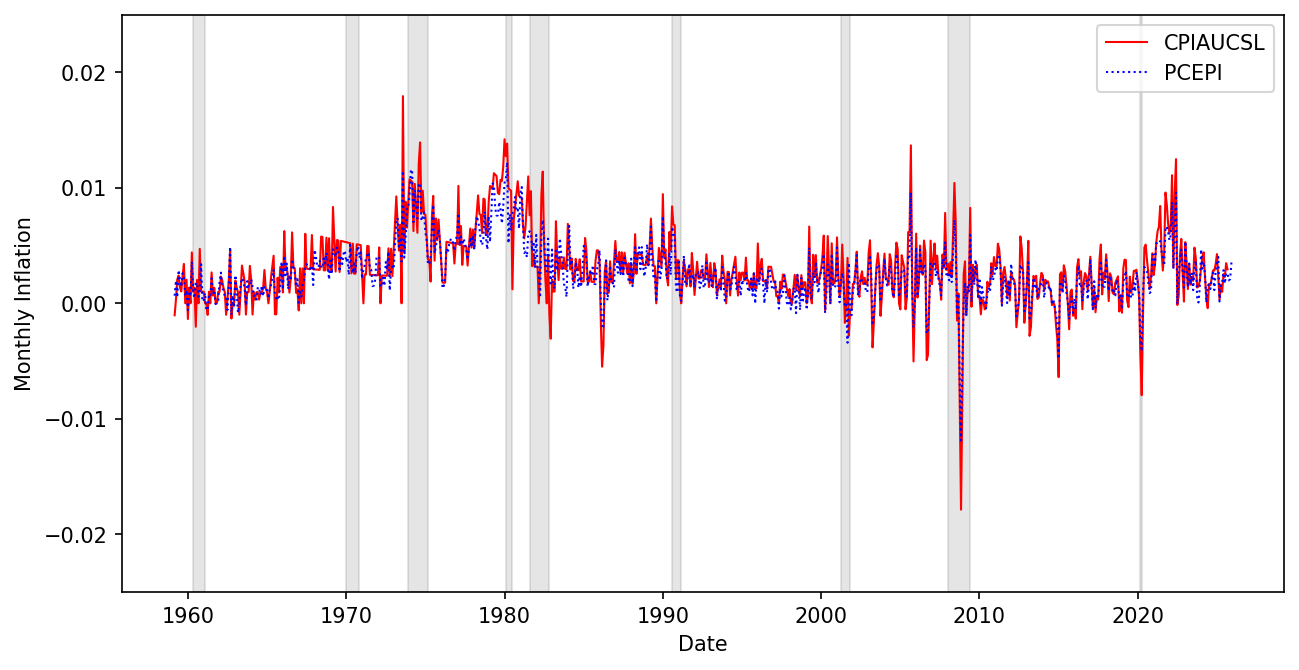

In [101]:
# plot CPIAUCSL and PCEPI over time
visualize_series(FRED_transformed, ["CPIAUCSL", "PCEPI"], "Monthly Inflation", -0.025, 0.025)

In [102]:
# drop the date
FRED_transformed = FRED_transformed.drop(columns = ["sasdate"])

In [103]:
# split train and test set
train_set, test_set = sample_split(FRED_transformed, 0.7)
# create feature engineering pipeline
x_feature_engineering = x_fe_pipeline(explained_var = 0.80)
y_feature_engineering = y_fe_pipeline()
# fit the feature engineering pipeline
x_feature_engineering.fit(train_set)
y_feature_engineering.fit(train_set)
# uses the fitted pipeline to transform the whole dataset
x_train = x_feature_engineering.transform(train_set)
x_test = x_feature_engineering.transform(test_set)
y_train = y_feature_engineering.transform(train_set)[["CPIAUCSL"]]
y_test = y_feature_engineering.transform(test_set)[["CPIAUCSL"]]

## MLP

In [104]:
# create aheads and lags for MLP
MLP_y_train, MLP_x_train, MLP_y_test, MLP_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, 1, 4, include_target = True)

/Users/yuhaohuo/Desktop/code/d200_project/inflation_forecast/feature_engineering.py:55: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_frame[f"{column}_{i}L"] = new_frame[column].shift(i)


Epoch [1/100], Train MSE: 0.0974, Test MSE: 0.1537
Epoch [2/100], Train MSE: 0.0960, Test MSE: 0.1513
Epoch [3/100], Train MSE: 0.0946, Test MSE: 0.1488
Epoch [4/100], Train MSE: 0.0931, Test MSE: 0.1463
Epoch [5/100], Train MSE: 0.0917, Test MSE: 0.1438
Epoch [6/100], Train MSE: 0.0902, Test MSE: 0.1411
Epoch [7/100], Train MSE: 0.0887, Test MSE: 0.1384
Epoch [8/100], Train MSE: 0.0873, Test MSE: 0.1357
Epoch [9/100], Train MSE: 0.0858, Test MSE: 0.1330
Epoch [10/100], Train MSE: 0.0843, Test MSE: 0.1303
Epoch [11/100], Train MSE: 0.0829, Test MSE: 0.1278
Epoch [12/100], Train MSE: 0.0814, Test MSE: 0.1253
Epoch [13/100], Train MSE: 0.0801, Test MSE: 0.1231
Epoch [14/100], Train MSE: 0.0789, Test MSE: 0.1211
Epoch [15/100], Train MSE: 0.0780, Test MSE: 0.1194
Epoch [16/100], Train MSE: 0.0770, Test MSE: 0.1176
Epoch [17/100], Train MSE: 0.0761, Test MSE: 0.1158
Epoch [18/100], Train MSE: 0.0752, Test MSE: 0.1140
Epoch [19/100], Train MSE: 0.0744, Test MSE: 0.1122
Epoch [20/100], Train

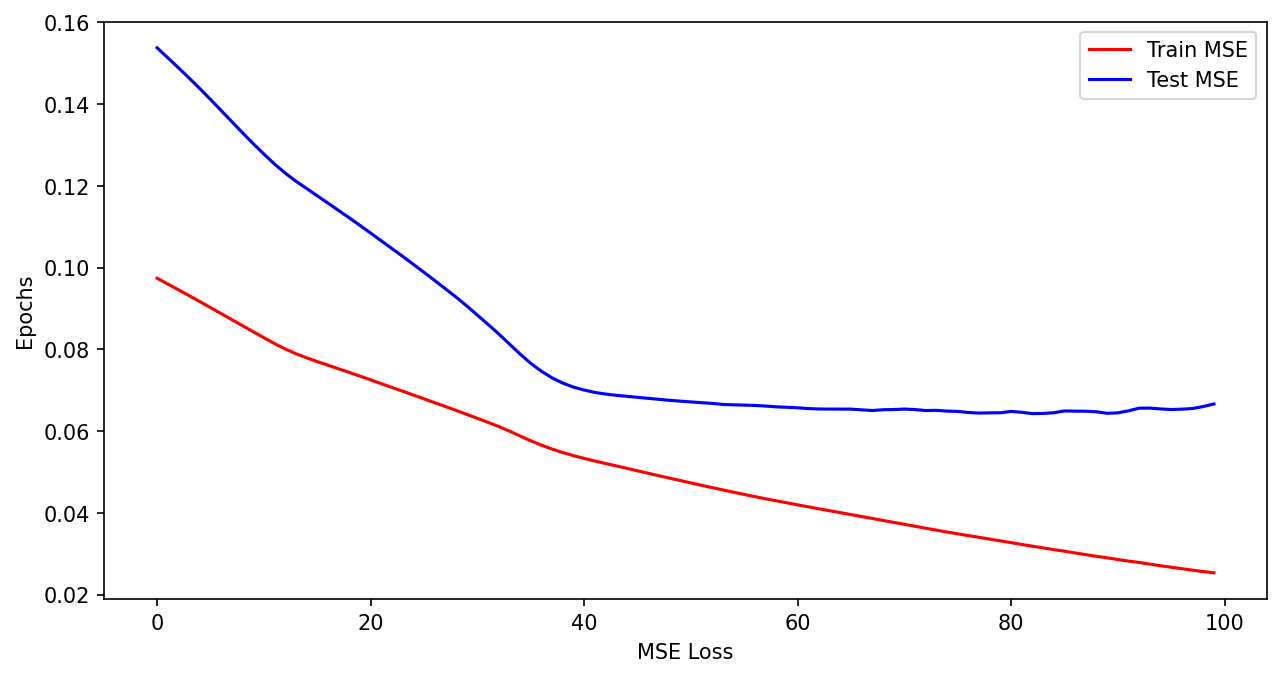

In [105]:
# train a MLP 
train_loader, test_loader = create_data_loaders(MLP_x_train, MLP_y_train, MLP_x_test, MLP_y_test, 128)
MLP = create_MLP(MLP_x_train, MLP_y_train)
train_loss_list, test_loss_list = MLP_training(MLP, train_loader, test_loader, 100, 0.0001)
visualize_loss(train_loss_list, test_loss_list)

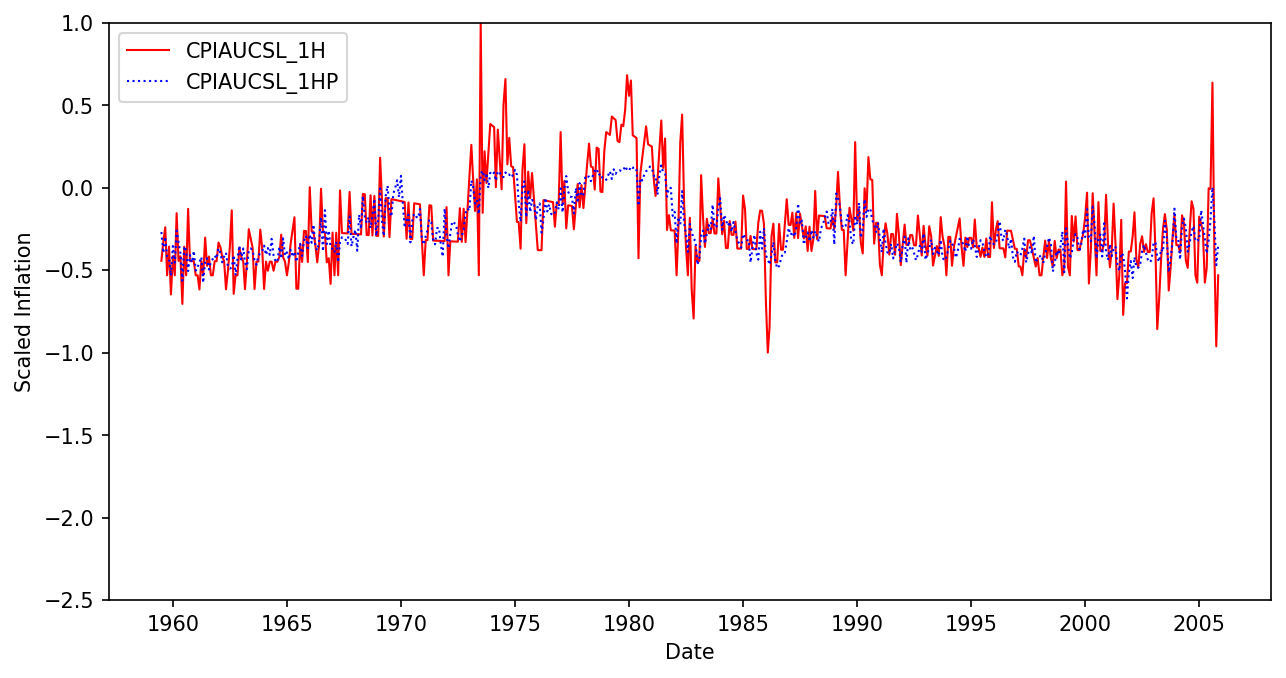

In [106]:
# plot prediction for training set
prediction = make_predict(MLP, MLP_x_train)
visualize_predict(prediction, MLP_y_train, 1, FRED_MD)

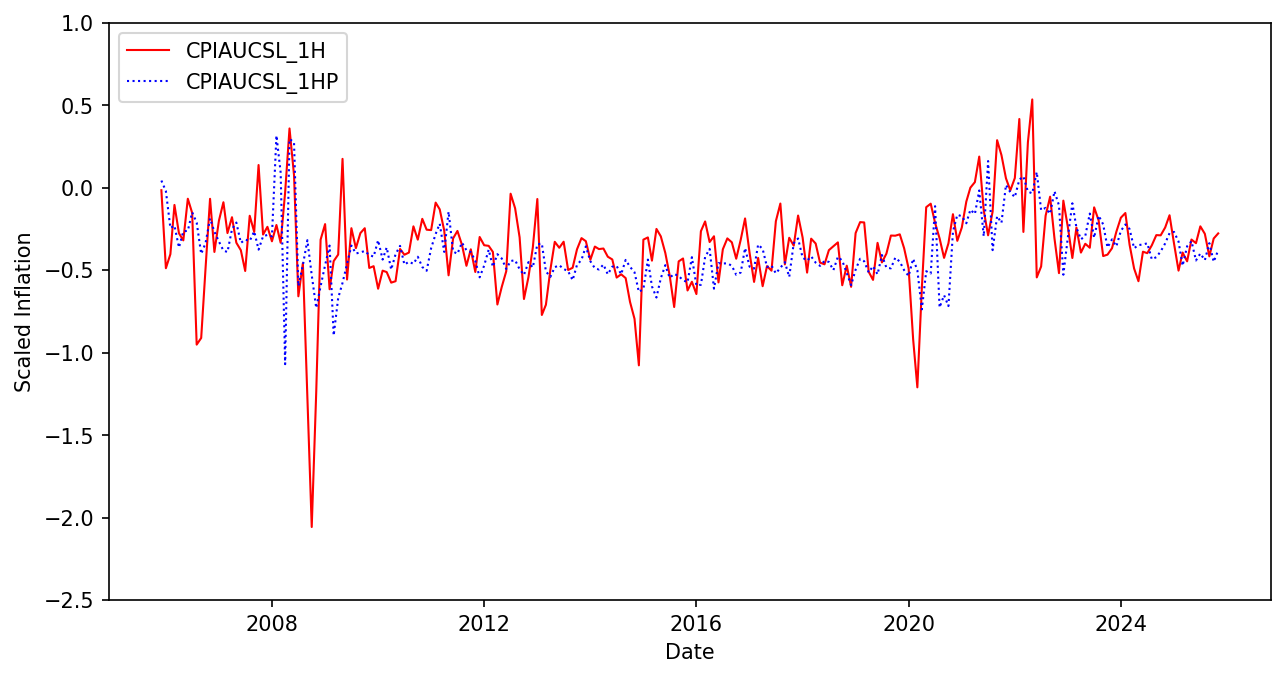

In [107]:
# plot prediction for testing set
prediction = make_predict(MLP, MLP_x_test)
visualize_predict(prediction, MLP_y_test, 1, FRED_MD)

## RNN

In [108]:
# create aheads and lags for RNN
RNN_y_train, RNN_x_train, RNN_y_test, RNN_x_test = create_ahead_lag(y_train, x_train, y_test, x_test, 1, 0)

In [109]:
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps") # Apple Silicon Metal Performance Shaders
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # GPU
else:
    DEVICE = torch.device("cpu") # CPU

class LSTM(nn.Module):
    def __init__(self, input_size, output_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = 1,
            batch_first=True
        )
        self.ffn = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )
    
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        last_hidden = h_n[-1]
        output = self.ffn(last_hidden)
        return output

RNN = LSTM(input_size=RNN_x_train.shape[1], hidden_size=32,  output_size=RNN_y_train.shape[1]).to(DEVICE)

In [110]:
X_train = torch.tensor(RNN_x_train.values, dtype=torch.float32)
Y_train = torch.tensor(RNN_y_train.values, dtype=torch.float32)
X_test = torch.tensor(RNN_x_test.values, dtype=torch.float32)
Y_test = torch.tensor(RNN_y_test.values, dtype=torch.float32)

In [111]:
class WindowData(Dataset):

    def __init__(self, X, Y, window):

        self.X = X
        self.Y = Y
        self.window = window

    def __len__(self):

        return len(self.X) - self.window

    def __getitem__(self, idx):

        X_seq = self.X[idx:idx+self.window]
        Y_target = self.Y[idx+self.window]

        return X_seq, Y_target

window_size = 24

train_dataset = WindowData(X_train, Y_train, window_size)
test_dataset = WindowData(X_test, Y_test, window_size)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

Epoch [1/100], Train MSE: 0.0892, Test MSE: 0.1478
Epoch [2/100], Train MSE: 0.0818, Test MSE: 0.1332
Epoch [3/100], Train MSE: 0.0759, Test MSE: 0.1201
Epoch [4/100], Train MSE: 0.0717, Test MSE: 0.1094
Epoch [5/100], Train MSE: 0.0688, Test MSE: 0.1003
Epoch [6/100], Train MSE: 0.0672, Test MSE: 0.0931
Epoch [7/100], Train MSE: 0.0663, Test MSE: 0.0872
Epoch [8/100], Train MSE: 0.0660, Test MSE: 0.0830
Epoch [9/100], Train MSE: 0.0658, Test MSE: 0.0801
Epoch [10/100], Train MSE: 0.0655, Test MSE: 0.0782
Epoch [11/100], Train MSE: 0.0649, Test MSE: 0.0770
Epoch [12/100], Train MSE: 0.0640, Test MSE: 0.0759
Epoch [13/100], Train MSE: 0.0627, Test MSE: 0.0745
Epoch [14/100], Train MSE: 0.0612, Test MSE: 0.0726
Epoch [15/100], Train MSE: 0.0594, Test MSE: 0.0704
Epoch [16/100], Train MSE: 0.0572, Test MSE: 0.0685
Epoch [17/100], Train MSE: 0.0548, Test MSE: 0.0669
Epoch [18/100], Train MSE: 0.0522, Test MSE: 0.0655
Epoch [19/100], Train MSE: 0.0497, Test MSE: 0.0650
Epoch [20/100], Train

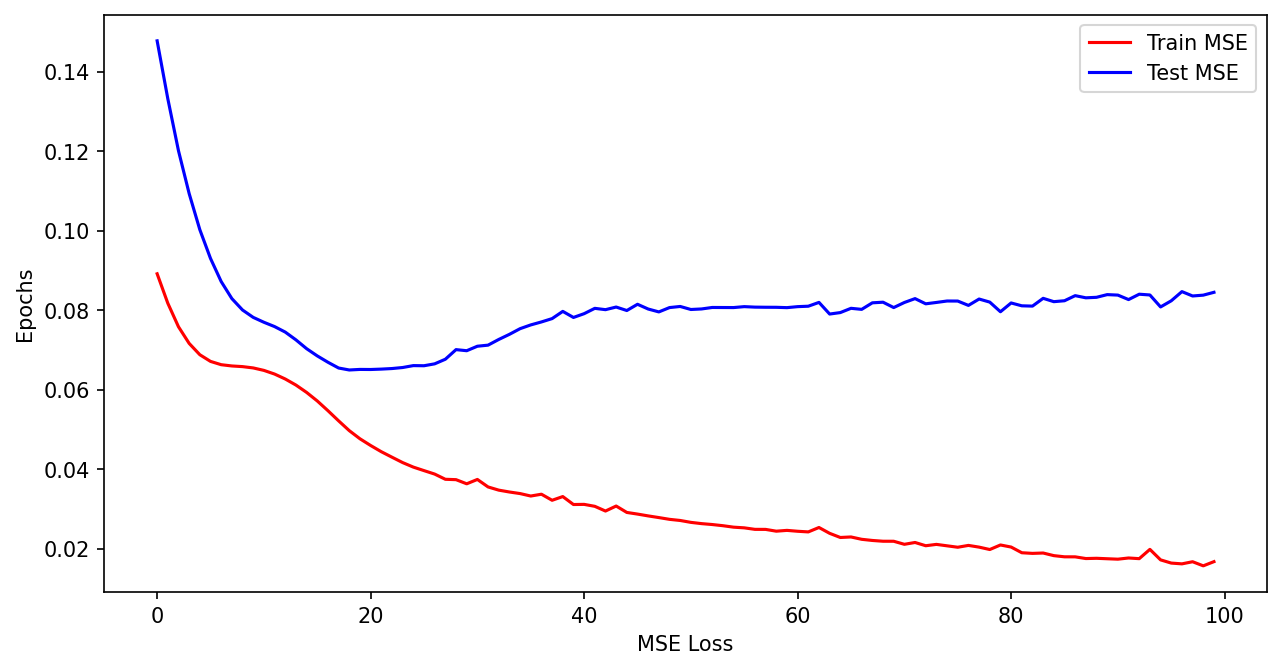

In [112]:
train_loss_list, test_loss_list = MLP_training(RNN, train_loader, test_loader, 100, 0.001)
visualize_loss(train_loss_list, test_loss_list)

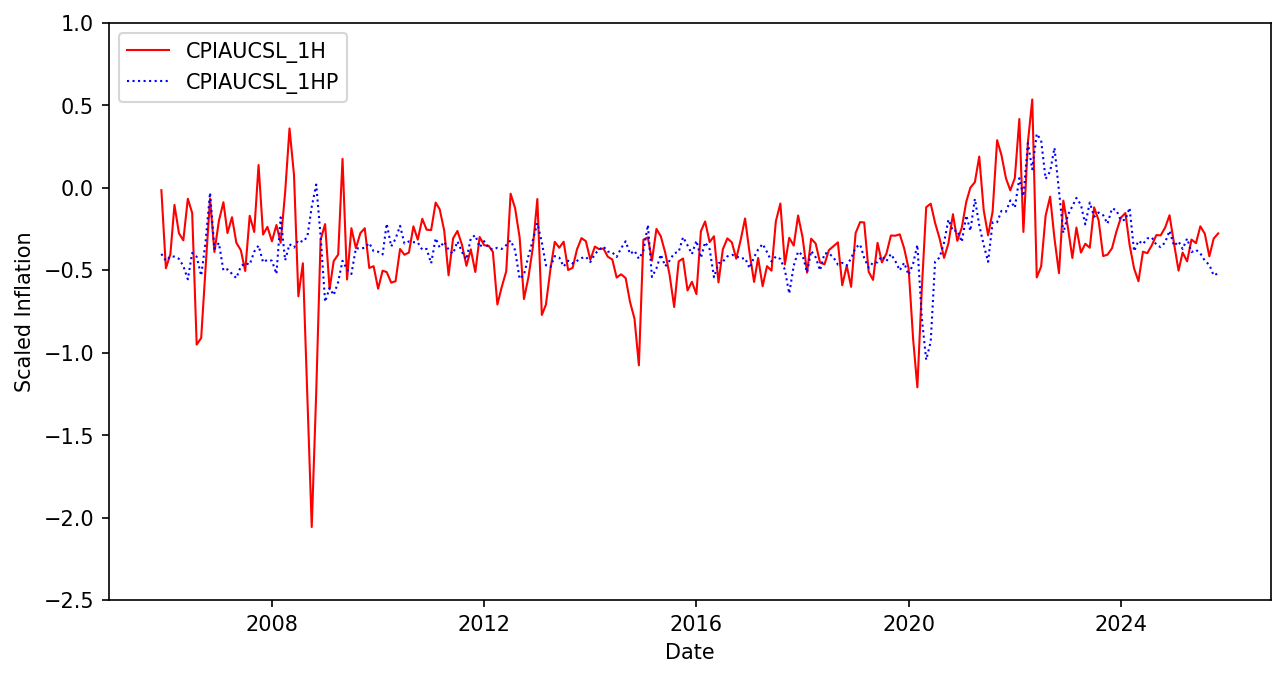

In [113]:
window = 48
X_combined = pd.concat(
    [RNN_x_test.tail(window), RNN_x_test]
)
X = X_combined.to_numpy()
X_tensor = []
for i in range(len(X) - window):
    X_tensor.append(X[i:i+window])
X_tensor = torch.tensor(X_tensor, dtype=torch.float32)
prediction = RNN(X_tensor.to(DEVICE))
prediction = pd.DataFrame(prediction.detach().to("cpu").numpy())
visualize_predict(prediction, RNN_y_test, 1, FRED_MD)

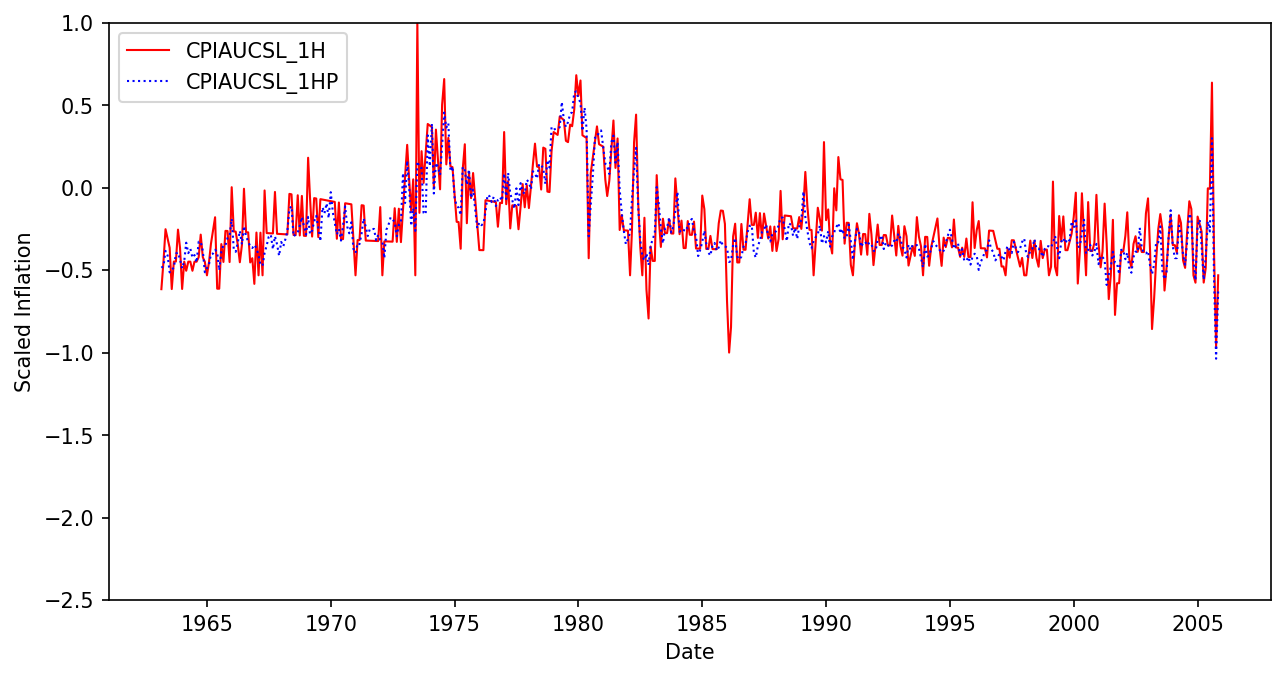

In [114]:
window = 48
X = RNN_x_train.to_numpy()
X_tensor = []
for i in range(len(X) - window):
    X_tensor.append(X[i:i+window])
X_tensor = torch.tensor(X_tensor, dtype=torch.float32)
prediction = RNN(X_tensor.to(DEVICE))
prediction = pd.DataFrame(prediction.detach().to("cpu").numpy())
visualize_predict(prediction, RNN_y_train[48:], 1, FRED_MD)